# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

Energie voor opwarming: 105307.79 J
Energie voor verdamping: 40680.00 J
Energie nuttig(theorie): 145987.79 J
Totaal energie: 161258.79 J
Verschil: 15271.00 J


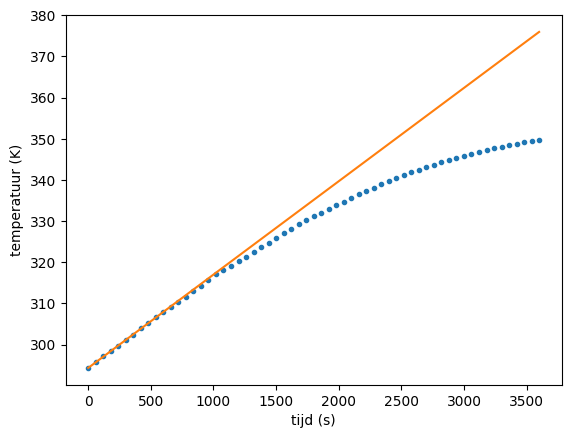

In [14]:
#Er wordt aangenomen dat er een constant vermogen is geleverd tijdens het experiment.
#Ook dat de eerste 10 min alle energie naar het opwarmen gaat.
#Er is geen rekening gehouden met opwarmen van de beker zelf of andere verliezen.

#In het vervolg kan er gebruik gemaakt worden van een Joule-meter en een geisoleerde beker. Ook kan er real-time naar de massa gekeken worden.

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data=np.loadtxt('tempmetingen.csv', delimiter=';', skiprows=1)
t=data[:,0] * 60 
T=data[:,1] + 273.15  
m_beker = 820.8e-3
m_start = 1292.9e-3
m_eind = 1274.9e-3
cwater = 4186
T_start = 21.2 + 273.15
T_eind = 76.6 + 273.15
delta_T = T_eind - T_start
Lv_water = 2.26e6

def func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(func, t[:11], T[:11])

t_as = np.linspace(min(t), max(t), 1000)

plt.figure()
plt.xlabel('tijd (s)')
plt.ylabel('temperatuur (K)')
plt.plot(t, T, '.')
plt.plot(t_as, func(t_as, *popt), '-')

m_verdampt = (m_start - m_beker)-(m_eind - m_beker)
Q_opwarm = (m_eind-m_beker) * cwater * delta_T
Q_verdampt = m_verdampt * Lv_water
Q_nuttig = Q_opwarm + Q_verdampt

P_watt = (m_start-m_beker) * cwater * popt[0] 
Q_totaal = P_watt * (max(t) - min(t))

print(f"Energie voor opwarming: {Q_opwarm:.2f} J")
print(f"Energie voor verdamping: {Q_verdampt:.2f} J")
print(f"Energie nuttig(theorie): {Q_nuttig:.2f} J")
print(f"Totaal energie: {Q_totaal:.2f} J")
verschil = Q_totaal - Q_nuttig
print(f"Verschil: {verschil:.2f} J")